# 3 — Modeling

This notebook trains and compares three models:
1. **Hourly Baseline** — historical average by (day_of_week, hour)
2. **LightGBM Spike Classifier** — binary spike detection
3. **LightGBM Price Regressor** — LMP level prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath("../src"))

import warnings
warnings.filterwarnings('ignore')

from pjm_spike_forecast.data import build_demo_dataset, load_lmp, load_weather, merge_lmp_weather
from pjm_spike_forecast.features import build_feature_matrix, get_feature_columns
from pjm_spike_forecast.models import HourlyBaseline, SpikeClassifier, PriceRegressor
from pjm_spike_forecast.evaluation import classification_metrics, regression_metrics

lmp = load_lmp("../data/raw/nyiso_lmp.csv")
weather = load_weather("../data/raw/weather.csv")
df = merge_lmp_weather(lmp, weather)
# df = build_demo_dataset(n_days=365, seed=42)
feat_df = build_feature_matrix(df)
feature_cols = get_feature_columns(feat_df)

# 80/20 temporal split
split = int(len(feat_df) * 0.8)
train = feat_df.iloc[:split]
test = feat_df.iloc[split:]
X_train, X_test = train[feature_cols], test[feature_cols]
print(f"Train: {len(train)} rows ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test:  {len(test)} rows ({test.index.min().date()} → {test.index.max().date()})")

Train: 20900 rows (2022-01-08 → 2024-05-28)
Test:  5225 rows (2024-05-28 → 2024-12-31)


## 3.1 — Hourly Baseline

In [3]:
baseline = HourlyBaseline()
baseline.fit(train)

bl_price = baseline.predict_price(test)
bl_spike = baseline.predict_spike(test)

bl_reg = regression_metrics(test["lmp"].values, bl_price)
bl_clf = classification_metrics(test["spike"].values, bl_spike)

print("Baseline Price Metrics:")
for k, v in bl_reg.items():
    print(f"  {k}: {v:.4f}")
print("\nBaseline Spike Metrics:")
for k, v in bl_clf.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Baseline Price Metrics:
  rmse: 37.8383
  mae: 25.7250
  mape: 77.4703
  r2: -0.1237

Baseline Spike Metrics:
  accuracy: 0.9522
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  true_pos: 0
  false_pos: 0
  true_neg: 4975
  false_neg: 250


## 3.2 — LightGBM Spike Classifier

In [4]:
clf = SpikeClassifier()
clf.fit(X_train, train["spike"])

spike_pred = clf.predict(X_test)
spike_proba = clf.predict_proba(X_test)

clf_metrics = classification_metrics(test["spike"].values, spike_pred, spike_proba)
print("LightGBM Spike Classifier:")
for k, v in clf_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

LightGBM Spike Classifier:
  accuracy: 0.9504
  precision: 0.4879
  recall: 0.7280
  f1: 0.5843
  true_pos: 182
  false_pos: 191
  true_neg: 4784
  false_neg: 68
  auc_roc: 0.9704
  avg_precision: 0.6086


## 3.3 — LightGBM Price Regressor

In [5]:
reg = PriceRegressor()
reg.fit(X_train, train["lmp"])

price_pred = reg.predict(X_test)
reg_metrics = regression_metrics(test["lmp"].values, price_pred)
print("LightGBM Price Regressor:")
for k, v in reg_metrics.items():
    print(f"  {k}: {v:.4f}")

LightGBM Price Regressor:
  rmse: 17.2031
  mae: 6.4846
  mape: 13.6398
  r2: 0.7677


## 3.4 — Side-by-Side Comparison

In [6]:
comparison = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R²"],
    "Baseline": [bl_reg["rmse"], bl_reg["mae"], bl_reg["r2"]],
    "LightGBM": [reg_metrics["rmse"], reg_metrics["mae"], reg_metrics["r2"]],
})
print(comparison.to_string(index=False))

print(f"\nLightGBM RMSE improvement over baseline: "
      f"{(1 - reg_metrics['rmse'] / bl_reg['rmse']) * 100:.1f}%")

Metric  Baseline  LightGBM
  RMSE 37.838267 17.203122
   MAE 25.725039  6.484611
    R² -0.123721  0.767721

LightGBM RMSE improvement over baseline: 54.5%


## 3.5 — Feature Importance (SHAP)

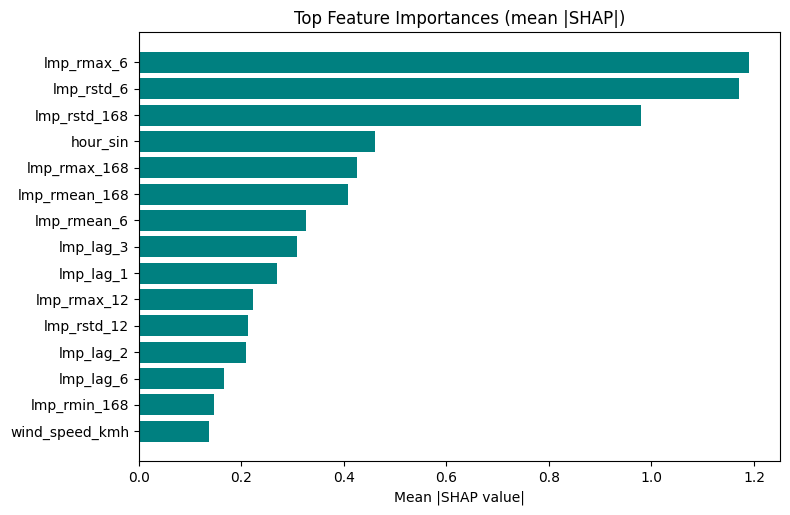


Top 10 features by SHAP importance:
      feature  mean_abs_shap
   lmp_rmax_6       1.191207
   lmp_rstd_6       1.169982
 lmp_rstd_168       0.978889
     hour_sin       0.459825
 lmp_rmax_168       0.424883
lmp_rmean_168       0.408448
  lmp_rmean_6       0.327055
    lmp_lag_3       0.308162
    lmp_lag_1       0.268940
  lmp_rmax_12       0.222322


In [7]:
from pjm_spike_forecast.evaluation import compute_shap_importance
from pjm_spike_forecast.visualization import plot_feature_importance

shap_df = compute_shap_importance(clf, X_test, max_samples=500)
fig = plot_feature_importance(shap_df, top_n=15)
plt.show()

print("\nTop 10 features by SHAP importance:")
print(shap_df.head(10).to_string(index=False))